#  Task 2: News Category Classification

**Goal:** Classify news articles into categories (Sports, Business, Politics, Technology, etc.)  
**Dataset:** AG News (via scikit-learn / Hugging Face datasets) 

**Approach:** Full ML pipeline — Preprocessing -> Vectorization -> Multiclass Classification  

---
### Pipeline Overview
```
Raw Text -> Preprocessing -> TF-IDF Vectorization -> Classifier -> Evaluation -> Visualization
```

##  Step 1: Install & Import Dependencies

In [2]:
# Install required libraries (run once)
!pip install datasets scikit-learn pandas numpy matplotlib seaborn wordcloud nltk xgboost lightgbm --quiet

In [12]:
import warnings
import re
import time
warnings.filterwarnings('ignore')

# ── Data Handling 
import numpy as np
import pandas as pd

# ── NLP / Text Processing 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ── Feature Engineering 
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import xgboost as xgb
import lightgbm as lgb

# ── Pipeline & Model Selection 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

# ── Evaluation 
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter



In [ ]:
# ── Dataset 
from datasets import load_dataset

# ── Style 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_colwidth', 120)

print(' All libraries imported successfully!')

In [13]:
# Download NLTK assets
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(resource, quiet=True)

print(' NLTK resources downloaded!')

 NLTK resources downloaded!


---
##  Step 2: Load the AG News Dataset

In [14]:
print('Loading AG News dataset from Hugging Face...')
dataset = load_dataset('ag_news')

# AG News label mapping
LABEL_MAP = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

# Convert to DataFrames
df_train = pd.DataFrame(dataset['train']).rename(columns={'label': 'category_id'})
df_test  = pd.DataFrame(dataset['test']).rename(columns={'label': 'category_id'})

# Map integer labels → readable category names
df_train['category'] = df_train['category_id'].map(LABEL_MAP)
df_test['category']  = df_test['category_id'].map(LABEL_MAP)

print(f'\n Dataset Summary:')
print(f'  Training samples : {len(df_train):,}')
print(f'  Test samples     : {len(df_test):,}')
print(f'  Categories       : {list(LABEL_MAP.values())}')

Loading AG News dataset from Hugging Face...

 Dataset Summary:
  Training samples : 120,000
  Test samples     : 7,600
  Categories       : ['World', 'Sports', 'Business', 'Sci/Tech']


In [15]:
# Peek at the data
df_train.head(5)

,text,category_id,category
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cyn...",2,Business
1,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a rep...",2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and th...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from...,2,Business
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil prices, toppling ...",2,Business


In [16]:
# Basic info
print(' DataFrame Info')
df_train.info()
print('\n Class Distribution (Train)')
print(df_train['category'].value_counts())

 DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   text         120000 non-null  object
 1   category_id  120000 non-null  int64 
 2   category     120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB

 Class Distribution (Train)
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


---
##  Step 3: Exploratory Data Analysis (EDA)

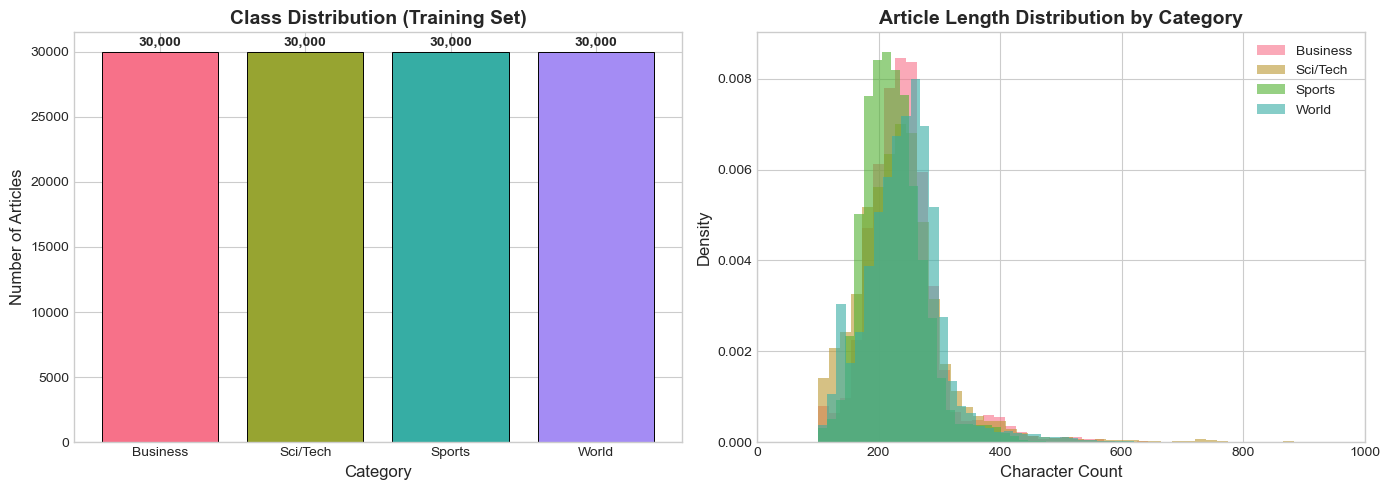


Avg article length: 236 characters
Max article length: 1,012 characters


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Class Distribution
category_counts = df_train['category'].value_counts()
bars = axes[0].bar(category_counts.index, category_counts.values,
                   color=sns.color_palette('husl', len(category_counts)),
                   edgecolor='black', linewidth=0.7)
axes[0].set_title('Class Distribution (Training Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
for bar, count in zip(bars, category_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Plot 2: Article Length Distribution
df_train['text_length'] = df_train['text'].apply(len)
for cat in df_train['category'].unique():
    subset = df_train[df_train['category'] == cat]['text_length']
    axes[1].hist(subset, bins=50, alpha=0.6, label=cat, density=True)
axes[1].set_title('Article Length Distribution by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Count', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend()
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAvg article length: {df_train["text_length"].mean():.0f} characters')
print(f'Max article length: {df_train["text_length"].max():,} characters')

---
##  Step 4: Text Preprocessing Pipeline

Steps: **Lowercase -> Remove noise -> Tokenize -> Remove stopwords -> Lemmatize**

In [18]:
class TextPreprocessor:
    """
    Production-grade text preprocessing pipeline.
    Handles: lowercasing, noise removal, tokenization,
             stopword removal, and lemmatization.
    """

    def __init__(self):
        self.lemmatizer   = WordNetLemmatizer()
        self.stop_words   = set(stopwords.words('english'))
        # Preserve informative words often in stop list for news
        self.stop_words   -= {'not', 'no', 'nor', 'against', 'up', 'down'}

    def _clean(self, text: str) -> str:
        """Remove URLs, HTML tags, punctuation, and extra whitespace."""
        text = text.lower()
        text = re.sub(r'http\S+|www\.\S+', '', text)       
        # URLs
        
        text = re.sub(r'<.*?>', '', text)                   
        # HTML tags
        text = re.sub(r'[^a-z\s]', ' ', text)              
        # keep only letters
        text = re.sub(r'\s+', ' ', text).strip()           
        # collapse spaces
        return text

    def _tokenize(self, text: str) -> list:
        """Tokenize and filter short/stop tokens."""
        tokens = word_tokenize(text)
        return [
            tok for tok in tokens
            if tok not in self.stop_words and len(tok) > 2
        ]

    def _lemmatize(self, tokens: list) -> list:
        """Lemmatize each token."""
        return [self.lemmatizer.lemmatize(tok) for tok in tokens]

    def preprocess(self, text: str) -> str:
        """Full pipeline: clean -> tokenize -> remove stopwords -> lemmatize."""
        cleaned  = self._clean(text)
        tokens   = self._tokenize(cleaned)
        lemmas   = self._lemmatize(tokens)
        return ' '.join(lemmas)

    def fit_transform(self, texts):
        """Apply preprocess to a list/Series of texts."""
        return [self.preprocess(t) for t in texts]


# ── Demo 
preprocessor = TextPreprocessor()
sample = df_train['text'].iloc[0]
print('ORIGINAL :', sample[:200])
print()
print('PROCESSED:', preprocessor.preprocess(sample)[:200])

ORIGINAL : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

PROCESSED: wall bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green


In [19]:
# ── Apply preprocessing to all splits 
print('Preprocessing training data...')
t0 = time.time()
df_train['text_clean'] = preprocessor.fit_transform(df_train['text'])
print(f'  Train done in {time.time()-t0:.1f}s')

print('Preprocessing test data...')
t0 = time.time()
df_test['text_clean'] = preprocessor.fit_transform(df_test['text'])
print(f'  Test done in {time.time()-t0:.1f}s')

print('\n Preprocessing complete!')
df_train[['text', 'text_clean', 'category']].head(3)

Preprocessing training data...
  Train done in 135.1s
Preprocessing test data...
  Test done in 6.4s

 Preprocessing complete!


,text,text_clean,category
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cyn...",wall bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green,Business
1,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a rep...",carlyle look toward commercial aerospace reuters reuters private investment firm carlyle group reputation making wel...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and th...,oil economy cloud stock outlook reuters reuters soaring crude price plus worry economy outlook earnings expected han...,Business


---
##  Step 5: Feature Engineering — TF-IDF Vectorization

In [21]:
# TF-IDF with unigrams + bigrams for richer features
tfidf = TfidfVectorizer(
    max_features   = 50_000,      
    # top 50k terms
    ngram_range    = (1, 2),      
    # unigrams and bigrams
    min_df         = 3,           
    # ignore very rare terms
    max_df         = 0.90,        
    # ignore overly common terms
    sublinear_tf   = True,        
    # apply log(tf) — standard for text
    strip_accents  = 'unicode',
    analyzer       = 'word'
)

X_train_tfidf = tfidf.fit_transform(df_train['text_clean'])
X_test_tfidf  = tfidf.transform(df_test['text_clean'])
y_train       = df_train['category_id'].values
y_test        = df_test['category_id'].values

print(f'TF-IDF matrix shape:')
print(f'  Train : {X_train_tfidf.shape}  (samples × features)')
print(f'  Test  : {X_test_tfidf.shape}')
print(f'  Vocabulary size: {len(tfidf.vocabulary_):,}')

TF-IDF matrix shape:
  Train : (120000, 50000)  (samples × features)
  Test  : (7600, 50000)
  Vocabulary size: 50,000


---
##  Step 6: Train Multiclass Classifiers

In [22]:
# ── Define all models
models = {
    'Logistic Regression': LogisticRegression(
        C=5.0, max_iter=1000, solver='saga',
        multi_class='multinomial', n_jobs=-1, random_state=42
    ),
    'Linear SVM': LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, n_jobs=-1,
        random_state=42, class_weight='balanced'
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        n_jobs=-1, random_state=42, tree_method='hist'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, num_leaves=63, learning_rate=0.1,
        n_jobs=-1, random_state=42, verbose=-1
    )
}

# ── Train & Evaluate 
results = {}

for name, model in models.items():
    print(f'\n Training: {name}...')
    t0 = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - t0

    y_pred    = model.predict(X_test_tfidf)
    acc       = accuracy_score(y_test, y_pred)
    results[name] = {
        'model'      : model,
        'y_pred'     : y_pred,
        'accuracy'   : acc,
        'train_time' : train_time
    }
    print(f'    Accuracy: {acc:.4f} | Train time: {train_time:.1f}s')


 Training: Logistic Regression...
    Accuracy: 0.9167 | Train time: 29.4s

 Training: Linear SVM...
    Accuracy: 0.9197 | Train time: 12.6s

 Training: Random Forest...
    Accuracy: 0.8979 | Train time: 1609.3s

 Training: XGBoost...
    Accuracy: 0.8858 | Train time: 3349.7s

 Training: LightGBM...
    Accuracy: 0.9157 | Train time: 1524.8s


---
##  Step 7: Model Comparison

In [23]:
# Summary DataFrame
results_df = pd.DataFrame([
    {'Model': name, 'Accuracy': v['accuracy'], 'Train Time (s)': round(v['train_time'], 2)}
    for name, v in results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(' Model Leaderboard ')
print(results_df.to_string(index=False))

 Model Leaderboard 
              Model  Accuracy  Train Time (s)
         Linear SVM  0.919737           12.61
Logistic Regression  0.916711           29.40
           LightGBM  0.915658         1524.77
      Random Forest  0.897895         1609.32
            XGBoost  0.885789         3349.70


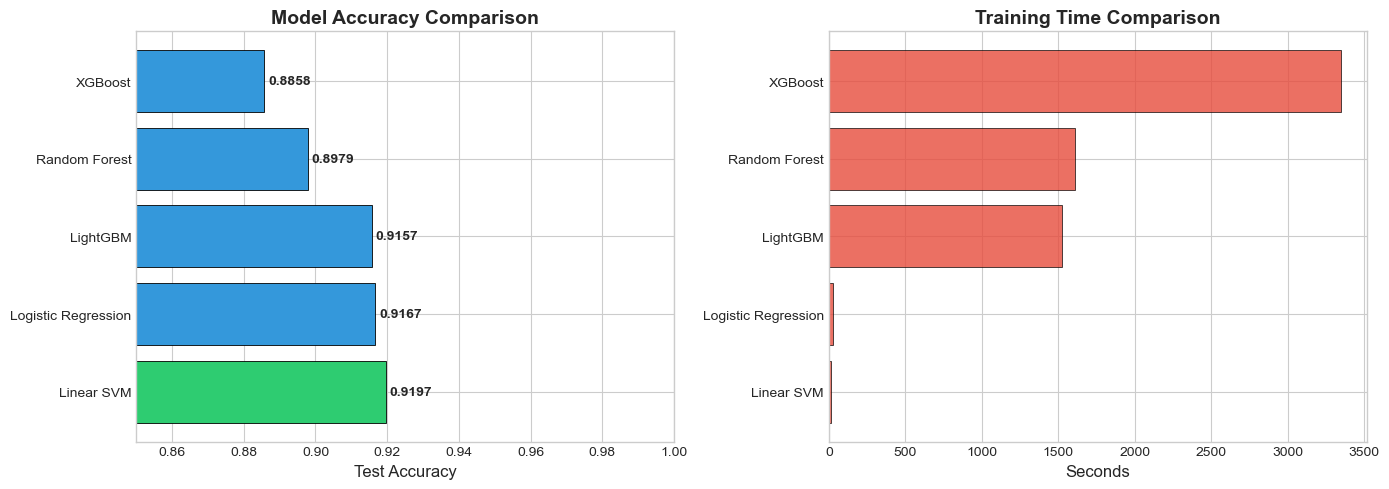

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Bar Chart 
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = axes[0].barh(results_df['Model'], results_df['Accuracy'],
                    color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Test Accuracy', fontsize=12)
axes[0].set_xlim(0.85, 1.0)
for bar, acc in zip(bars, results_df['Accuracy']):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')

# ── Training Time Bar Chart 
axes[1].barh(results_df['Model'], results_df['Train Time (s)'],
             color='#e74c3c', edgecolor='black', linewidth=0.6, alpha=0.8)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Seconds', fontsize=12)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Step 8: Best Model — Detailed Evaluation

In [25]:
# Select best model
best_name  = results_df.iloc[0]['Model']
best_pred  = results[best_name]['y_pred']
best_model = results[best_name]['model']

print(f' Best Model: {best_name}')
print(f'   Accuracy: {results[best_name]["accuracy"]:.4f}\n')

# Full classification report
label_names = list(LABEL_MAP.values())
print(' Classification Report ')
print(classification_report(y_test, best_pred, target_names=label_names))

 Best Model: Linear SVM
   Accuracy: 0.9197

 Classification Report 
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



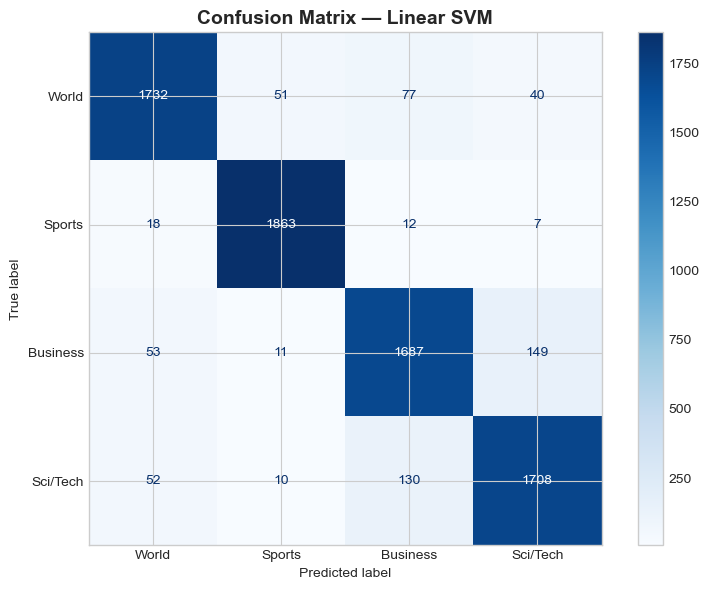

In [26]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Step 9 : Word Frequency Visualization per Category

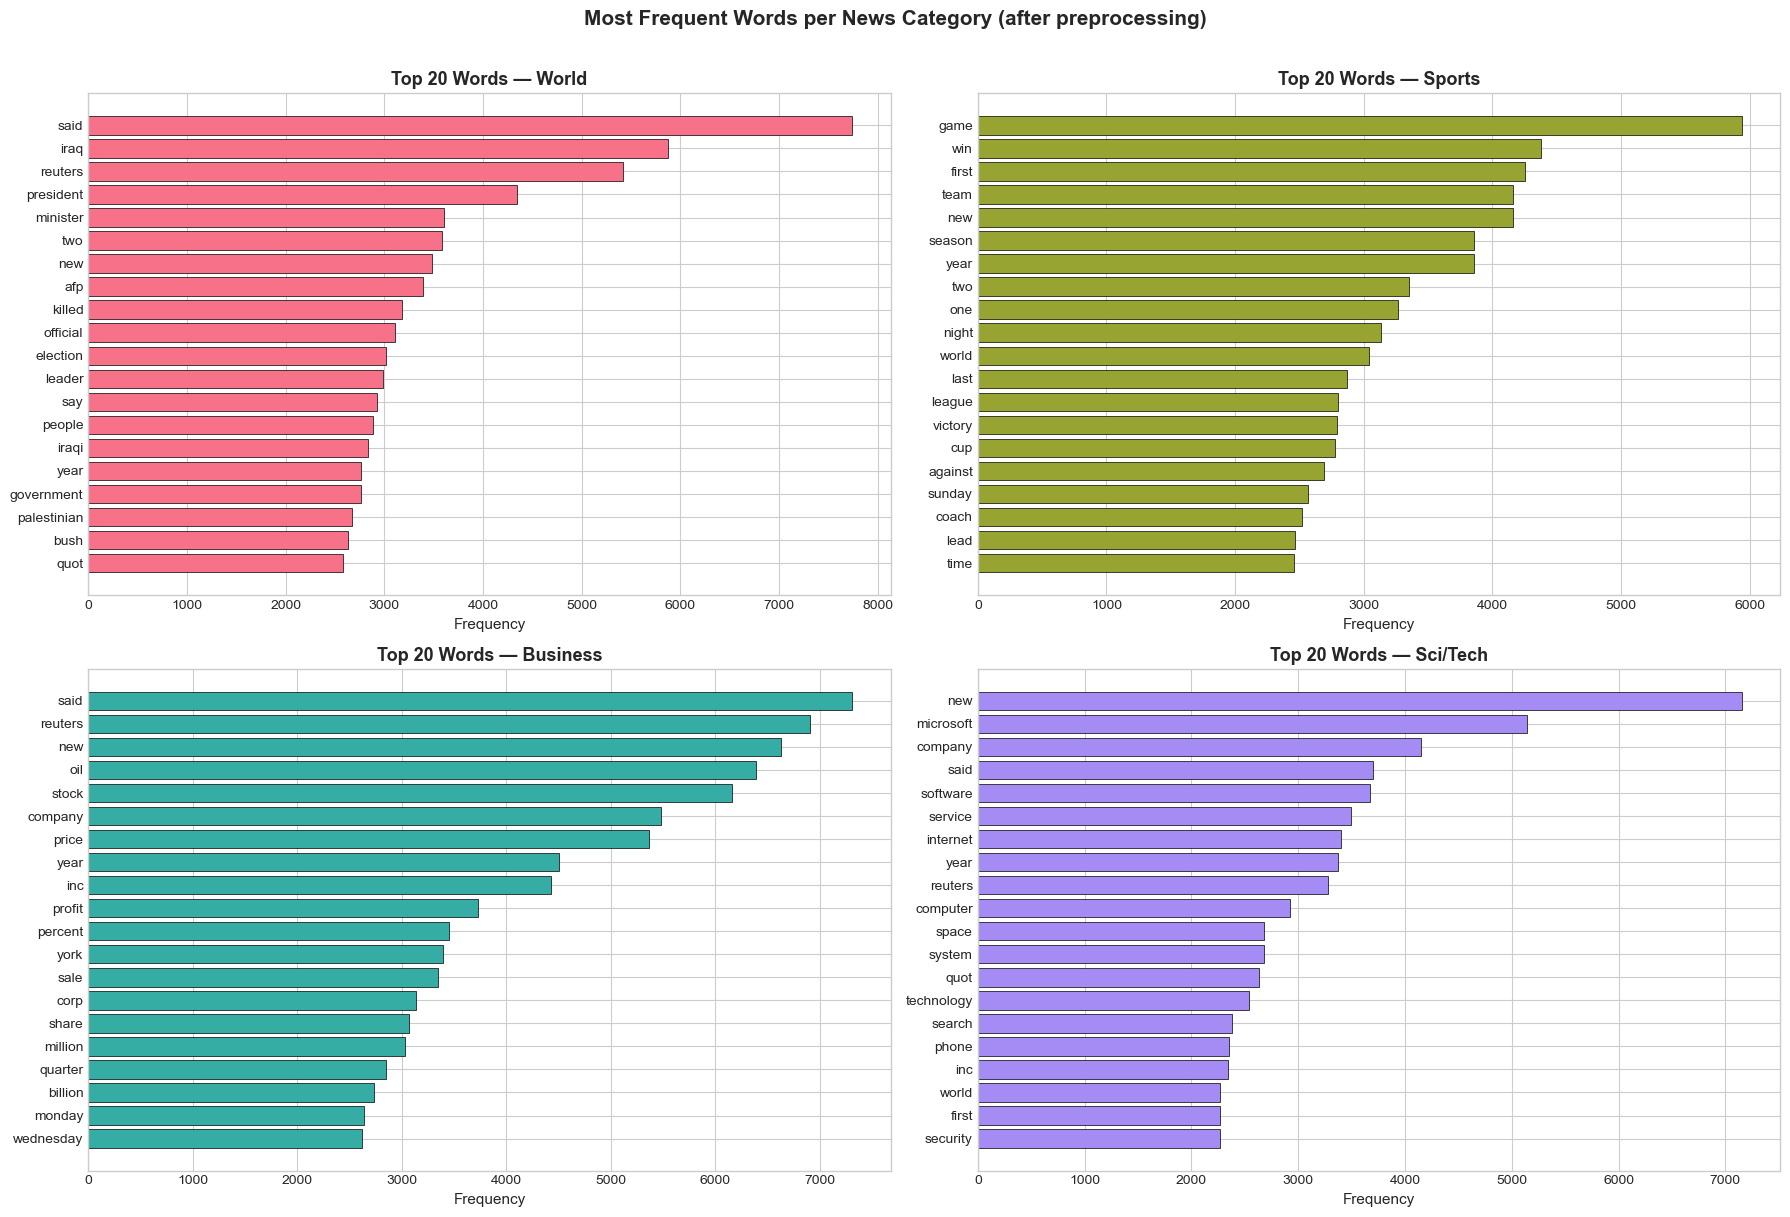

In [27]:
def get_top_words(df, category, n=20):
    """Get top N most frequent words for a given category."""
    texts = ' '.join(df[df['category'] == category]['text_clean'])
    words = texts.split()
    return Counter(words).most_common(n)

categories = list(LABEL_MAP.values())
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

palette = sns.color_palette('husl', len(categories))

for i, cat in enumerate(categories):
    top_words = get_top_words(df_train, cat, n=20)
    words, counts = zip(*top_words)
    
    axes[i].barh(list(reversed(words)), list(reversed(counts)),
                 color=palette[i], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Top 20 Words — {cat}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Frequency', fontsize=11)
    axes[i].tick_params(axis='y', labelsize=10)

plt.suptitle('Most Frequent Words per News Category (after preprocessing)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top_words_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

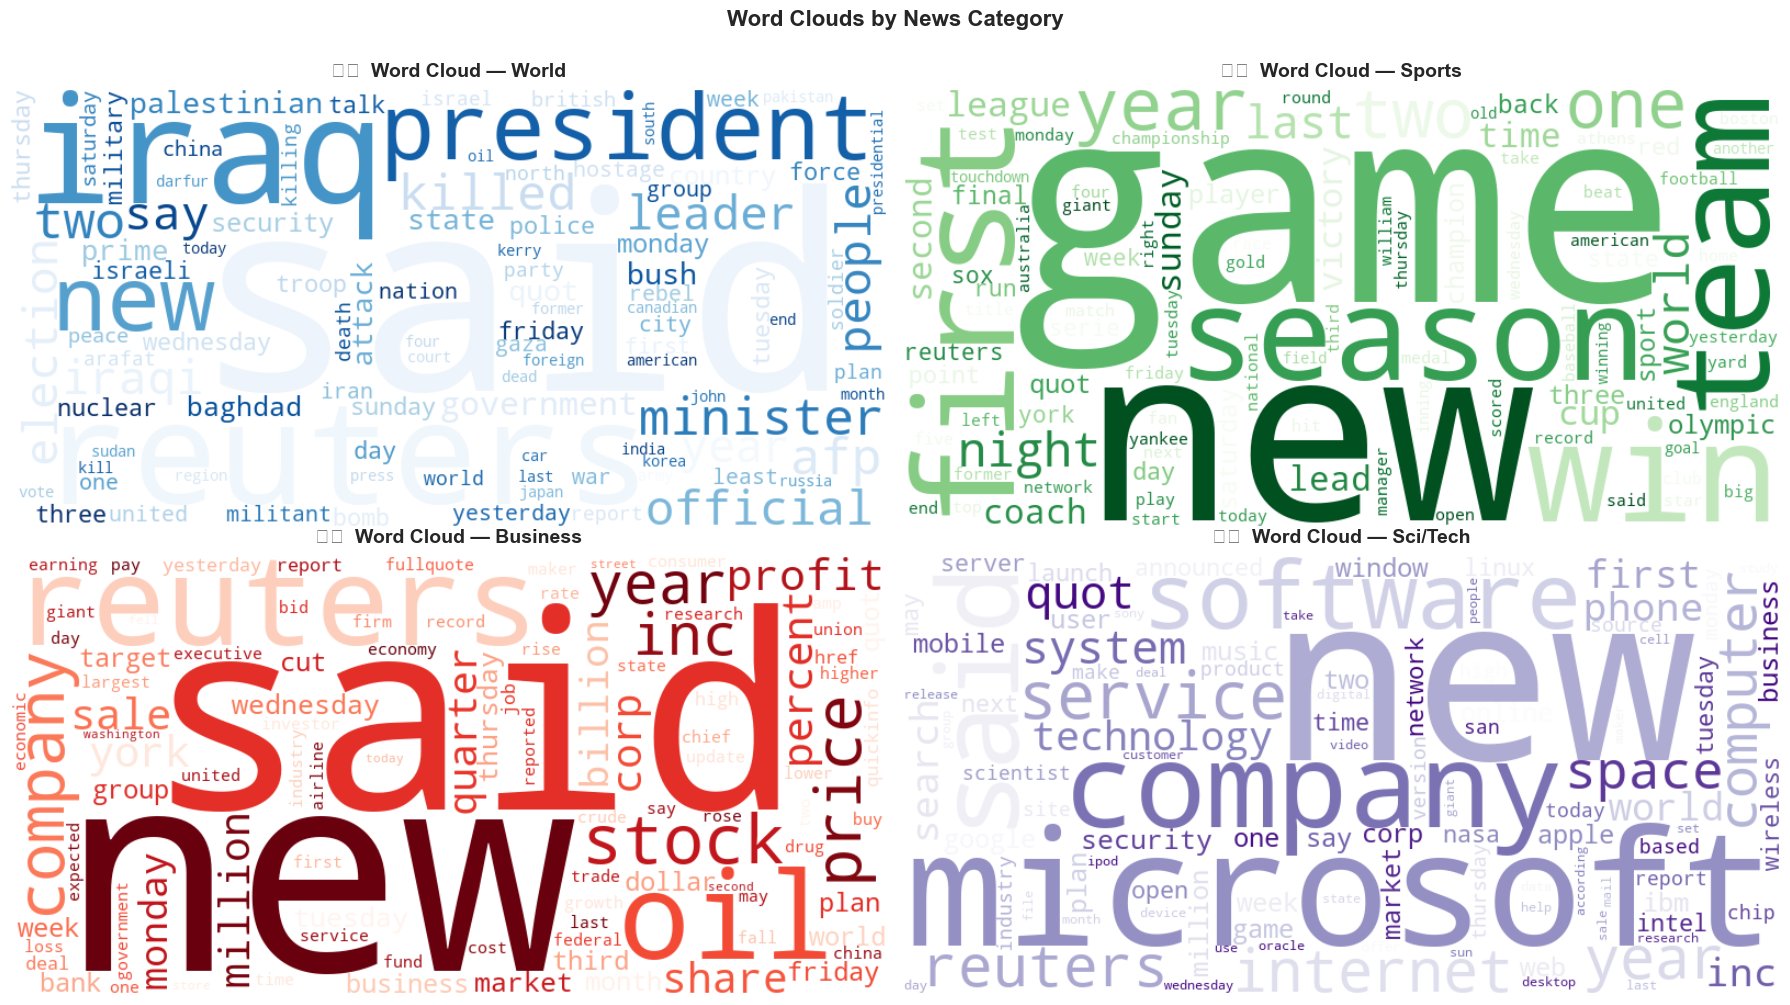

In [28]:
# ── Word Clouds per Category ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

wc_colors = ['Blues', 'Greens', 'Reds', 'Purples']

for i, cat in enumerate(categories):
    text_blob = ' '.join(df_train[df_train['category'] == cat]['text_clean'])
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=wc_colors[i],
        max_words=100,
        collocations=False
    ).generate(text_blob)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'☁️  Word Cloud — {cat}', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Word Clouds by News Category', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Step 10: Inference — Classify New Articles

In [29]:
def predict_category(texts, model, vectorizer, preprocessor, label_map):
    """
    End-to-end prediction pipeline.
    Args:
        texts      : list of raw article strings
        model      : trained classifier
        vectorizer : fitted TF-IDF vectorizer
        preprocessor: TextPreprocessor instance
        label_map  : dict mapping int -> category name
    Returns:
        list of predicted category names
    """
    cleaned    = [preprocessor.preprocess(t) for t in texts]
    vectorized = vectorizer.transform(cleaned)
    preds      = model.predict(vectorized)
    return [label_map[p] for p in preds]


# ── Test on custom articles 
new_articles = [
    "The stock market fell sharply today as inflation fears gripped investors on Wall Street.",
    "Manchester United secured a dramatic late victory with a goal in injury time.",
    "Scientists have developed a new AI model capable of detecting diseases from blood samples.",
    "The Senate passed a new climate change bill with bipartisan support after weeks of debate.",
    "Apple announced its next-generation chip with unprecedented performance gains at its annual event."
]

predictions = predict_category(new_articles, best_model, tfidf, preprocessor, LABEL_MAP)

print(' Custom Article Predictions ')
for article, pred in zip(new_articles, predictions):
    print(f'\n "{article[:80]}..."')
    print(f'     Predicted Category: [{pred}]')

 Custom Article Predictions 

 "The stock market fell sharply today as inflation fears gripped investors on Wall..."
     Predicted Category: [Business]

 "Manchester United secured a dramatic late victory with a goal in injury time...."
     Predicted Category: [Sports]

 "Scientists have developed a new AI model capable of detecting diseases from bloo..."
     Predicted Category: [Sci/Tech]

 "The Senate passed a new climate change bill with bipartisan support after weeks ..."
     Predicted Category: [Sci/Tech]

 "Apple announced its next-generation chip with unprecedented performance gains at..."
     Predicted Category: [Sci/Tech]


---
##  Step 11: Final Summary

In [30]:
print('=' * 60)
print('         NEWS CATEGORY CLASSIFICATION — SUMMARY')
print('=' * 60)
print(f'Dataset          : AG News (Hugging Face)')
print(f'Categories       : {list(LABEL_MAP.values())}')
print(f'Training samples : {len(df_train):,}')
print(f'Test samples     : {len(df_test):,}')
print(f'Vocabulary size  : {len(tfidf.vocabulary_):,} terms')
print(f'Features         : TF-IDF (unigrams + bigrams)')
print()
print('--- Model Results ---')
for _, row in results_df.iterrows():
    flag = '' if row['Model'] == best_name else '  '
    print(f"{flag}  {row['Model']:<22} Accuracy: {row['Accuracy']:.4f}  |  Time: {row['Train Time (s)']}s")
print()
print(f'Best Model       : {best_name}')
print(f'Best Accuracy    : {results[best_name]["accuracy"]:.4f}')
print('=' * 60)

         NEWS CATEGORY CLASSIFICATION — SUMMARY
Dataset          : AG News (Hugging Face)
Categories       : ['World', 'Sports', 'Business', 'Sci/Tech']
Training samples : 120,000
Test samples     : 7,600
Vocabulary size  : 50,000 terms
Features         : TF-IDF (unigrams + bigrams)

--- Model Results ---
  Linear SVM             Accuracy: 0.9197  |  Time: 12.61s
    Logistic Regression    Accuracy: 0.9167  |  Time: 29.4s
    LightGBM               Accuracy: 0.9157  |  Time: 1524.77s
    Random Forest          Accuracy: 0.8979  |  Time: 1609.32s
    XGBoost                Accuracy: 0.8858  |  Time: 3349.7s

Best Model       : Linear SVM
Best Accuracy    : 0.9197
